In [4]:
data_dir = '/Users/zoecas/Documents/data/'
#file = list(sorted(data_dir.glob('SWOT_563/SWOT_L2_LR_SSH_*.nc')))[5]
file = "SWOT_L2_LR_SSH_Expert_045_216_20260131T225821_20260131T234949_PID0_01.nc"
data = load_swot_l2_basic(data_dir+file)

In [5]:
# --------------------------------------------------------------------------- #
# Geometry helpers
# --------------------------------------------------------------------------- #

def _haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * EARTH_RADIUS_KM * np.arcsin(np.sqrt(np.minimum(1.0, a)))


def along_track_distance_km(lat: np.ndarray, lon: np.ndarray,
                             axis: int = 0) -> np.ndarray:
    """
    Cumulative along-track distance (km) computed along `axis`, using a
    representative cross-track index (median pixel column) so that a
    single along-track distance axis can be shared by all pixel columns
    of a swath.

    lat, lon : (num_lines, num_pixels) arrays (NaNs allowed away from the
               reference column).
    """
    if lat.ndim == 1:
        ref_lat, ref_lon = lat, lon
    else:
        ref_col = lat.shape[1] // 2
        ref_lat = lat[:, ref_col]
        ref_lon = lon[:, ref_col]
        # fall back to nearest valid column if the reference is empty
        if np.all(np.isnan(ref_lat)):
            valid_cols = [c for c in range(lat.shape[1])
                          if not np.all(np.isnan(lat[:, c]))]
            if not valid_cols:
                raise ValueError("No valid latitude data found to build "
                                  "along-track distance axis.")
            ref_col = valid_cols[len(valid_cols) // 2]
            ref_lat = lat[:, ref_col]
            ref_lon = lon[:, ref_col]

    # interpolate over any internal NaNs in the reference track so the
    # distance axis itself is always well defined
    ref_lat = _interp_nan_1d(ref_lat)
    ref_lon = _interp_nan_1d(ref_lon)

    d = np.zeros_like(ref_lat)
    d[1:] = _haversine_km(ref_lat[:-1], ref_lon[:-1], ref_lat[1:], ref_lon[1:])
    return np.cumsum(d)


def _interp_nan_1d(x: np.ndarray) -> np.ndarray:
    """Linearly interpolate interior NaNs in a 1-D array; edge NaNs are
    filled with the nearest valid value (no extrapolation of slope)."""
    x = np.asarray(x, dtype=float).copy()
    n = len(x)
    idx = np.arange(n)
    good = ~np.isnan(x)
    if good.sum() == 0:
        return x
    if good.sum() < n:
        x[~good] = np.interp(idx[~good], idx[good], x[good])
    return x


# --------------------------------------------------------------------------- #
# Swath splitting
# --------------------------------------------------------------------------- #

def split_left_right_swaths(cross_track_distance: np.ndarray):
    """
    Return boolean column masks (left_mask, right_mask) over the
    cross-track (pixel) dimension, identifying which pixel columns
    belong to the left swath (negative cross-track distance), the right
    swath (positive), and implicitly excluding the nadir-gap columns
    (NaN or exactly 0 cross-track distance), which fall into neither
    mask.

    cross_track_distance may be 1-D (num_pixels,) or 2-D
    (num_lines, num_pixels); if 2-D, the per-pixel sign is taken from
    the median across lines (the swath geometry is essentially constant
    along track).
    """
    xt = np.asarray(cross_track_distance, dtype=float)
    if xt.ndim == 2:
        xt = np.nanmedian(xt, axis=0)

    left_mask = xt < 0
    right_mask = xt > 0
    return left_mask, right_mask


# --------------------------------------------------------------------------- #
# Core spectral computation
# --------------------------------------------------------------------------- #

def _segment_bounds(distance_km: np.ndarray, segment_length_km: float,
                     overlap: float = 0.0):
    """Yield (i_start, i_end) index pairs splitting `distance_km` into
    along-track segments of length `segment_length_km`, with optional
    fractional overlap (0 <= overlap < 1)."""
    if not (0.0 <= overlap < 1.0):
        raise ValueError("overlap must be in [0, 1).")
    step_km = segment_length_km * (1.0 - overlap)
    total = distance_km[-1]
    starts_km = np.arange(distance_km[0], total - segment_length_km + 1e-9, step_km)
    if len(starts_km) == 0:
        # pass shorter than one segment: use whole pass as a single segment
        starts_km = np.array([distance_km[0]])

    bounds = []
    for s_km in starts_km:
        e_km = s_km + segment_length_km
        i0 = int(np.searchsorted(distance_km, s_km, side="left"))
        i1 = int(np.searchsorted(distance_km, e_km, side="right"))
        if i1 - i0 < 8:  # need a minimum number of samples to FFT meaningfully
            continue
        bounds.append((i0, i1))
    return bounds


def compute_swath_spectra(
    ssha: np.ndarray,
    latitude: np.ndarray,
    longitude: np.ndarray,
    swath_mask: np.ndarray,
    swath_name: str,
    segment_length_km: float,
    along_track_spacing_km: Optional[float] = None,
    overlap: float = 0.0,
    max_gap_fraction: float = 0.25,
    detrend: str = "linear",
    window: str = "hann",
    min_pixels_per_segment: int = 3,
) -> PassSpectrumResult:
    """
    Compute along-track wavenumber spectra for ONE swath (left or right)
    of a SWOT L2 LR Basic pass.

    Parameters
    ----------
    ssha : (num_lines, num_pixels) array
        SSH or SSHA field for the full pass (both swaths + gap), NaN
        where invalid/flagged.
    latitude, longitude : (num_lines, num_pixels) arrays
        Geolocation, same shape as ssha.
    swath_mask : (num_pixels,) boolean array
        Pixel columns belonging to this swath (output of
        split_left_right_swaths).
    swath_name : str
        "left" or "right" (for bookkeeping only).
    segment_length_km : float
        Length of each along-track segment in km. This is the key
        resolution/statistics trade-off parameter: longer segments give
        better low-wavenumber resolution but fewer independent segments
        to average.
    along_track_spacing_km : float, optional
        Nominal along-track sample spacing in km. If None, it is
        estimated from the data (median spacing of the along-track
        distance axis). Needed to convert FFT bin index to a physical
        wavenumber (cycles/km) and to resample onto a uniform grid if
        the native sampling is irregular.
    overlap : float
        Fractional overlap between consecutive segments (0 <= overlap < 1).
    max_gap_fraction : float
        Maximum allowed fraction of NaN samples within a segment
        (per pixel column) before that column is excluded from the
        segment average; if too few columns remain valid
        (< min_pixels_per_segment) the whole segment is dropped. This is
        how land, the unsampled nadir-adjacent pixels, and isolated
        data gaps are handled.
    detrend : str
        Passed to scipy.signal detrending ("linear", "constant", or
        False).
    window : str
        Taper window name (passed to scipy.signal.get_window), default
        Hann, standard in the SWOT cal/val literature.
    min_pixels_per_segment : int
        Minimum number of valid cross-track pixel columns required to
        keep a segment.

    Returns
    -------
    PassSpectrumResult
    """
    ssha = np.asarray(ssha, dtype=float)
    cols = np.where(swath_mask)[0]
    if cols.size == 0:
        raise ValueError(f"No pixels found for swath '{swath_name}'.")

    sub_ssha = ssha[:, cols]
    sub_lat = latitude[:, cols]
    sub_lon = longitude[:, cols]

    distance_km = along_track_distance_km(sub_lat, sub_lon)

    if along_track_spacing_km is None:
        diffs = np.diff(distance_km)
        diffs = diffs[diffs > 0]
        along_track_spacing_km = float(np.median(diffs)) if diffs.size else 2.0

    bounds = _segment_bounds(distance_km, segment_length_km, overlap=overlap)

    # nperseg: convert segment length to sample count using the nominal
    # spacing, but in practice we just use the index range from
    # _segment_bounds and resample to a fixed length so all segments
    # share an identical, common wavenumber axis.
    nperseg = int(round(segment_length_km / along_track_spacing_km))
    nperseg = max(nperseg, 8)

    win = signal.get_window(window, nperseg)

    segments: list = []
    for seg_idx, (i0, i1) in enumerate(bounds):
        seg_ssha = sub_ssha[i0:i1, :]
        seg_lat = sub_lat[i0:i1, :]
        seg_lon = sub_lon[i0:i1, :]
        seg_dist = distance_km[i0:i1]

        if seg_ssha.shape[0] < 8:
            continue

        # Resample each column onto a uniform along-track grid of length
        # nperseg covering [seg_dist[0], seg_dist[0] + segment_length_km).
        uniform_dist = (seg_dist[0]
                         + np.arange(nperseg) * along_track_spacing_km)
        # discard segment if the uniform grid runs past available data
        if uniform_dist[-1] > seg_dist[-1] + along_track_spacing_km:
            continue

        col_psds = []
        any_gap_filled = False
        valid_fracs = []

        for c in range(seg_ssha.shape[1]):
            col = seg_ssha[:, c]
            valid = ~np.isnan(col)
            valid_frac = valid.mean() if len(col) else 0.0
            valid_fracs.append(valid_frac)

            if valid_frac < (1.0 - max_gap_fraction) or valid.sum() < 8:
                continue  # too many gaps / land in this column -> skip it

            # interpolate this column (in native sampling) onto the
            # uniform grid; NaNs interpolated only between valid points,
            # never extrapolated beyond the valid data range.
            good_dist = seg_dist[valid]
            good_val = col[valid]
            if good_dist[0] > uniform_dist[0] or good_dist[-1] < uniform_dist[-1]:
                # uniform grid would require extrapolation -> skip column
                continue

            resampled = np.interp(uniform_dist, good_dist, good_val)
            if valid_frac < 1.0:
                any_gap_filled = True

            resampled = signal.detrend(resampled, type=detrend) if detrend else resampled
            tapered = resampled * win

            freqs, pxx = signal.periodogram(
                tapered, fs=1.0 / along_track_spacing_km,
                window="boxcar",  # window already applied manually above
                detrend=False, scaling="density",
            )
            # correct for window power loss (since we applied `win`
            # ourselves rather than letting periodogram do it, so we can
            # reuse the exact same window energy normalisation here)
            win_norm = (win ** 2).mean()
            pxx = pxx / win_norm

            col_psds.append(pxx)

        n_pixels_used = len(col_psds)
        if n_pixels_used < min_pixels_per_segment:
            continue

        mean_pxx = np.mean(np.stack(col_psds, axis=0), axis=0)

        segments.append(SegmentSpectrum(
            swath=swath_name,
            segment_index=seg_idx,
            wavenumber=freqs,
            psd=mean_pxx,
            n_pixels_used=n_pixels_used,
            lat_mean=float(np.nanmean(seg_lat)),
            lat_min=float(np.nanmin(seg_lat)),
            lat_max=float(np.nanmax(seg_lat)),
            lon_mean=float(np.nanmean(seg_lon)),
            along_track_distance_start_km=float(seg_dist[0]),
            along_track_distance_end_km=float(seg_dist[-1]),
            valid_fraction=float(np.mean(valid_fracs)) if valid_fracs else 0.0,
            gap_filled=any_gap_filled,
        ))

    if segments:
        wavenumber = segments[0].wavenumber
        mean_psd = np.mean(np.stack([s.psd for s in segments], axis=0), axis=0)
    else:
        wavenumber = np.array([])
        mean_psd = np.array([])

    return PassSpectrumResult(
        swath=swath_name,
        wavenumber=wavenumber,
        mean_psd=mean_psd,
        n_segments_used=len(segments),
        n_segments_total=len(bounds),
        segments=segments,
    )


def compute_pass_spectra(
    ssha: np.ndarray,
    latitude: np.ndarray,
    longitude: np.ndarray,
    cross_track_distance: np.ndarray,
    segment_length_km: float,
    along_track_spacing_km: Optional[float] = None,
    overlap: float = 0.0,
    max_gap_fraction: float = 0.25,
    detrend: str = "linear",
    window: str = "hann",
    min_pixels_per_segment: int = 3,
):
    """
    Top-level convenience function: compute along-track wavenumber
    spectra for BOTH swaths (left and right) of a SWOT L2 LR Basic pass,
    handling land/NaN gaps and the nadir gap automatically.

    Parameters mirror compute_swath_spectra(); see that function's
    docstring for full details.

    Returns
    -------
    dict with keys "left" and "right", each a PassSpectrumResult.
    """
    left_mask, right_mask = split_left_right_swaths(cross_track_distance)

    results = {}
    for name, mask in (("left", left_mask), ("right", right_mask)):
        results[name] = compute_swath_spectra(
            ssha=ssha,
            latitude=latitude,
            longitude=longitude,
            swath_mask=mask,
            swath_name=name,
            segment_length_km=segment_length_km,
            along_track_spacing_km=along_track_spacing_km,
            overlap=overlap,
            max_gap_fraction=max_gap_fraction,
            detrend=detrend,
            window=window,
            min_pixels_per_segment=min_pixels_per_segment,
        )
    return results




In [25]:
out = compute_pass_spectra(
        ssha=data["ssha"],
        latitude=data["latitude"],
        longitude=data["longitude"],
        cross_track_distance=data["cross_track_distance"],
        segment_length_km=256.0,
        overlap=0.5,
        max_gap_fraction=0.25,
    )

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_4360/3498093773.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(data['longitude'],data['latitude'],data['ssha'],vmax=0.5,vmin=-0.5,


(-60.0, 30.0)

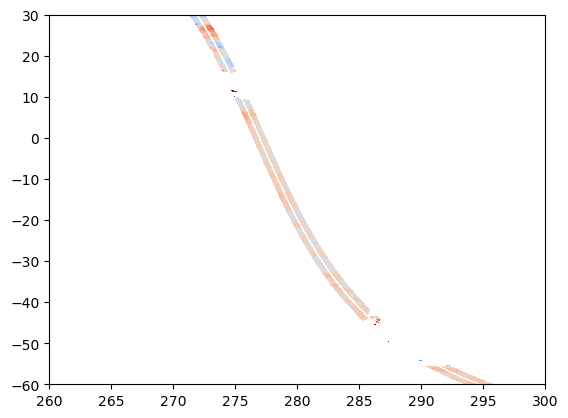

In [26]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()
ax.pcolormesh(data['longitude'],data['latitude'],data['ssha'],vmax=0.5,vmin=-0.5,
               cmap='coolwarm')
ax.set_xlim(260,300);ax.set_ylim(-60,30)

In [47]:
def segments_to_dataset(spectra: dict) -> xr.Dataset:
    """
    Convert the dict-of-PassSpectrumResult returned by compute_pass_spectra()
    into a single xarray.Dataset stacking every retained segment (both
    swaths) along a `segment` dimension.

    Assumes all segments share the same wavenumber axis (true by
    construction in compute_swath_spectra, since every segment is
    resampled to the same `nperseg`).
    """
    all_segments = []
    wavenumber = None
    for swath_name, res in spectra.items():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        all_segments.extend(res.segments)

    if not all_segments:
        raise ValueError("No segments were retained for either swath; "
                          "nothing to put in a Dataset.")

    psd = np.stack([s.psd for s in all_segments], axis=0)  # (segment, wavenumber)

    ds = xr.Dataset(
        data_vars=dict(
            psd=(["segment", "wavenumber"], psd,
                 {"long_name": "Along-track SSH(A) power spectral density",
                  "units": "m^2 / (cycles/km)"}),
            lat_mean=(["segment"], [s.lat_mean for s in all_segments],
                      {"long_name": "Segment mean latitude", "units": "degrees_north"}),
            lat_min=(["segment"], [s.lat_min for s in all_segments],
                     {"units": "degrees_north"}),
            lat_max=(["segment"], [s.lat_max for s in all_segments],
                     {"units": "degrees_north"}),
            lon_mean=(["segment"], [s.lon_mean for s in all_segments],
                      {"long_name": "Segment mean longitude", "units": "degrees_east"}),
            along_track_distance_start_km=(["segment"],
                [s.along_track_distance_start_km for s in all_segments], {"units": "km"}),
            along_track_distance_end_km=(["segment"],
                [s.along_track_distance_end_km for s in all_segments], {"units": "km"}),
            n_pixels_used=(["segment"], [s.n_pixels_used for s in all_segments]),
            valid_fraction=(["segment"], [s.valid_fraction for s in all_segments]),
            gap_filled=(["segment"], [bool(s.gap_filled) for s in all_segments]),
            swath=(["segment"], [s.swath for s in all_segments]),
            segment_index=(["segment"], [s.segment_index for s in all_segments]),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber,
                        {"long_name": "Along-track wavenumber", "units": "cycles/km"}),
            segment=("segment", np.arange(len(all_segments))),
        ),
        attrs=dict(
            description="Per-segment along-track SSH(A) wavenumber PSD from SWOT L2 LR Expert, "
                         "computed with compute_pass_spectra().",
        ),
    )
    return ds


ds_segments = segments_to_dataset(out)
ds_segments

<xarray.Dataset> Size: 37kB
Dimensions:                        (segment: 58, wavenumber: 65)
Coordinates:
  * segment                        (segment) int64 464B 0 1 2 3 ... 54 55 56 57
  * wavenumber                     (wavenumber) float64 520B 0.0 ... 0.2499
Data variables:
    psd                            (segment, wavenumber) float64 30kB 0.05625...
    lat_mean                       (segment) float64 464B 28.65 27.51 ... -59.49
    lat_min                        (segment) float64 464B 27.47 26.33 ... -60.67
    lat_max                        (segment) float64 464B 29.83 28.69 ... -58.31
    lon_mean                       (segment) float64 464B 272.6 272.8 ... 293.7
    along_track_distance_start_km  (segment) float64 464B 6.528e+03 ... 1.651...
    along_track_distance_end_km    (segment) float64 464B 6.783e+03 ... 1.677...
    n_pixels_used                  (segment) int64 464B 27 27 27 27 ... 26 27 27
    valid_fraction                 (segment) float64 464B 0.7941 ... 0.7712
    gap_filled                     (segment) bool 58B False False ... True True
    swath                          (segment) <U5 1kB 'left' 'left' ... 'right'
    segment_index                  (segment) int64 464B 51 52 55 ... 112 128 129
Attributes:
    description:  Per-segment along-track SSH(A) wavenumber PSD from SWOT L2 ...

In [39]:
dict_out = {str(i): (['k'],s.psd) for i,s in enumerate(out['left'].segments)}

In [40]:
dict_out['k'] = out['left'].segments[0].wavenumber

In [44]:
out['left']

PassSpectrumResult(swath='left', wavenumber=array([0.        , 0.00390401, 0.00780801, 0.01171202, 0.01561602,
       0.01952003, 0.02342403, 0.02732804, 0.03123204, 0.03513605,
       0.03904005, 0.04294406, 0.04684806, 0.05075207, 0.05465607,
       0.05856008, 0.06246408, 0.06636809, 0.07027209, 0.0741761 ,
       0.07808011, 0.08198411, 0.08588812, 0.08979212, 0.09369613,
       0.09760013, 0.10150414, 0.10540814, 0.10931215, 0.11321615,
       0.11712016, 0.12102416, 0.12492817, 0.12883217, 0.13273618,
       0.13664018, 0.14054419, 0.14444819, 0.1483522 , 0.15225621,
       0.15616021, 0.16006422, 0.16396822, 0.16787223, 0.17177623,
       0.17568024, 0.17958424, 0.18348825, 0.18739225, 0.19129626,
       0.19520026, 0.19910427, 0.20300827, 0.20691228, 0.21081628,
       0.21472029, 0.21862429, 0.2225283 , 0.2264323 , 0.23033631,
       0.23424032, 0.23814432, 0.24204833, 0.24595233, 0.24985634]), mean_psd=array([2.61687646e-02, 9.89297112e-02, 6.86673417e-02, 1.43337830e-02,
   

In [8]:
ds_out=xr.Dataset({'mean_psd':(['k'],out['left'].mean_psd),'k':(['k'],out['left'].wavenumber)})

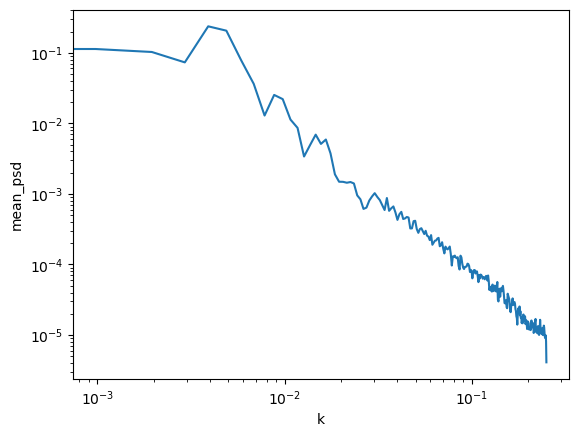

In [9]:
ds_out.mean_psd.plot(yscale='log',xscale='log')

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_4360/3498093773.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(data['longitude'],data['latitude'],data['ssha'],vmax=0.5,vmin=-0.5,


(-60.0, 30.0)

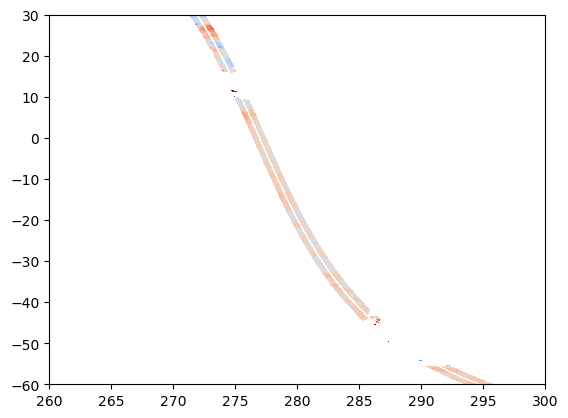

In [ ]:
# --------------------------------------------------------------------------- #
# Example usage
# --------------------------------------------------------------------------- #

if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser(
        description="Compute along-track SSH(A) wavenumber spectra from a "
                    "SWOT L2 LR Basic granule.")
    parser.add_argument("filepath", help="Path to SWOT_L2_LR_SSH_*_Basic*.nc")
    parser.add_argument("--ssh-var", default="ssha_karin_2")
    parser.add_argument("--segment-length-km", type=float, default=250.0)
    parser.add_argument("--overlap", type=float, default=0.5)
    parser.add_argument("--max-gap-fraction", type=float, default=0.25)
    args = parser.parse_args()

    data = load_swot_l2_basic(args.filepath, ssh_var=args.ssh_var)
    out = compute_pass_spectra(
        ssha=data["ssha"],
        latitude=data["latitude"],
        longitude=data["longitude"],
        cross_track_distance=data["cross_track_distance"],
        segment_length_km=args.segment_length_km,
        overlap=args.overlap,
        max_gap_fraction=args.max_gap_fraction,
    )

    for swath_name, res in out.items():
        print(f"[{swath_name}] {res.n_segments_used}/{res.n_segments_total} "
              f"segments used.")
        for seg in res.segments:
            print(f"   seg {seg.segment_index:3d}  lat {seg.lat_min:6.2f}..{seg.lat_max:6.2f}  "
                  f"n_pixels={seg.n_pixels_used}  valid_frac={seg.valid_fraction:.2f}")
